<a href="https://colab.research.google.com/github/SkillfulRheyme4/ai4g-portfolio-sambam/blob/main/Term%201/Week%205/hackathon/model_showdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Frame the problem

**Target:** whether a person struggles to live on their household income (yes/no).

**Positive class (1):** the person finds it "difficult" or "very difficult" to live on their present income.

**User and decision:** the debt-support team of a Dutch municipality. They decide who receives a letter with an offer of help, before debts build up.

**Worst mistake:** a false negative, meaning someone who struggles but gets no letter. The system exists to help people, and someone who is missed can fall deeper into debt. A false positive (a letter someone doesn't need) costs time and money, but much less.

**Main metric: F2.** F2 weighs recall more heavily than precision, but still counts precision. We do not use recall alone, because a model that sends everyone a letter would get a perfect recall while wasting a lot of money and time.

In [1]:
import os
import numpy as np
import pandas as pd

# Jupyter: use the copy in data/. Google Colab: download the same file from our GitHub repo.
DATA_URL = "https://raw.githubusercontent.com/SkillfulRheyme4/ai4g-portfolio-sambam/main/Term%201/Week%205/hackathon/data/ess_nl_rounds4-11.csv"
LOCAL_PATH = "data/ess_nl_rounds4-11.csv"

df = pd.read_csv(LOCAL_PATH if os.path.exists(LOCAL_PATH) else DATA_URL)
df.shape

(13890, 26)

## Step 2: Explore the data

**Size:** 13,890 rows and 26 columns. Each row is one interviewed person.

**Types:** all columns are numbers (answer codes), except four text columns that describe the file (`name`, `edition`, `proddate`, `cntry`). The codes are labels, not amounts: `mnactic = 6` ("retired") is not twice `mnactic = 3` ("unemployed").

In [2]:
# Column types and non-empty values per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13890 entries, 0 to 13889
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      13890 non-null  str    
 1   essround  13890 non-null  int64  
 2   edition   13890 non-null  float64
 3   proddate  13890 non-null  str    
 4   idno      13890 non-null  int64  
 5   cntry     13890 non-null  str    
 6   dweight   13890 non-null  float64
 7   pspwght   13890 non-null  float64
 8   pweight   13890 non-null  float64
 9   anweight  13890 non-null  float64
 10  prob      4838 non-null   float64
 11  stratum   4838 non-null   float64
 12  psu       4838 non-null   float64
 13  brncntr   13890 non-null  int64  
 14  hhmmb     13890 non-null  int64  
 15  gndr      13890 non-null  int64  
 16  agea      13890 non-null  int64  
 17  chldhm    9052 non-null   float64
 18  domicil   13890 non-null  int64  
 19  eisced    13890 non-null  int64  
 20  hincfel   13890 non-null  int64  
 21  

In [3]:
# Target: which answers occur?
df["hincfel"].value_counts().sort_index()

hincfel
1    7458
2    4875
3    1067
4     340
7      54
8      96
Name: count, dtype: int64

**Target:** `hincfel`. Answer 3 or 4 ("difficult" or "very difficult" to live on present income) becomes 1, and answer 1 or 2 becomes 0.
- We removed 150 rows with code 7 or 8 ("refusal" or "don't know"), because we don't know whether these people struggle.
- 13,740 rows remain, of which 1,407 (10%) struggle. The data is imbalanced: a model that always says "no" is already 90% accurate.

In [4]:
# Remove refusal/don't know (7, 8) and create the target
df = df[df["hincfel"].isin([1, 2, 3, 4])]
df["struggling"] = df["hincfel"].isin([3, 4]).astype(int)
df["struggling"].value_counts()

struggling
0    12333
1     1407
Name: count, dtype: int64

**Columns we do not use as input:**
- The 13 survey-administration columns (IDs, dates, weights), because they say nothing about the person.
- `hincfel`, because the target is made from it. Using it would be leakage.
- `hinctnta` (income), because the municipality does not know residents' income.
- `gndr` and `brncntr`, so that the model does not select people by sex or origin. We keep them aside to check in step 8 whether the model is fair. People born outside NL struggle almost 3 times as often (26% vs 9%).

In [5]:
# Share struggling per group: born in NL (1) or not (2)
df.groupby("brncntr")["struggling"].mean()

brncntr
1    0.086563
2    0.260592
7    0.000000
Name: struggling, dtype: float64

**Missing values in disguise:** codes such as 7/8/9, 77/88/99 and 777/888/999 mean "refusal", "don't know" or "no answer". We replace them with `NaN`, column by column. The rows stay in, and the Pipeline imputes the gaps later.

In [6]:
# Replace disguised missing values with NaN
missing_codes = {
    "agea": [999],
    "hhmmb": [77, 88, 99],
    "domicil": [7, 8, 9],
    "eisced": [77, 88, 99],
    "hincsrca": [77, 88, 99],
    "mnactic": [66, 77, 88, 99],
    "uemp3m": [7, 8, 9],
    "wkhtot": [777, 888, 999],
}
for col, codes in missing_codes.items():
    df[col] = df[col].replace(codes, np.nan)

df.isna().sum()

name             0
essround         0
edition          0
proddate         0
idno             0
cntry            0
dweight          0
pspwght          0
pweight          0
anweight         0
prob          8962
stratum       8962
psu           8962
brncntr          0
hhmmb            9
gndr             0
agea            21
chldhm        4778
domicil          7
eisced          10
hincfel          0
hincsrca        83
hinctnta         0
mnactic         54
uemp3m          30
wkhtot         295
struggling       0
dtype: int64

`chldhm` (children at home) was not asked in 2018–2023, so more than a third of it is empty. We drop this column.

In [7]:
# chldhm: share missing per survey round
df.groupby("essround")["chldhm"].apply(lambda x: x.isna().mean())

essround
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     1.0
10    1.0
11    1.0
Name: chldhm, dtype: float64

**Impossible values:** working hours 666 means "not applicable" (no job), so we replace it with 0. More than 100 hours per week is not realistic, so we set those 8 values to `NaN`.

In [8]:
# Working hours: 666 = no job, so 0 hours; more than 100 hours is impossible
df["wkhtot"] = df["wkhtot"].replace(666, 0)
df.loc[df["wkhtot"] > 100, "wkhtot"] = np.nan
df["wkhtot"].describe()

count    13437.000000
mean        33.397038
std         15.915051
min          0.000000
25%         24.000000
50%         36.000000
75%         40.000000
max        100.000000
Name: wkhtot, dtype: float64

**Duplicates:** there are no exact duplicate rows, and no respondent appears twice (same respondent number in the same round). Some different people give exactly the same answers on our 8 input columns and the target. With a handful of mostly categorical questions that is normal (for example two retired people in two-person households in a village). They are real, separate people, so we keep them; they are not copies of one row that could leak from train to test.

These cleaning steps learn nothing from the data. They are fixed rules from the codebook, which is why they can be done before the split.

In [9]:
# Exact duplicate rows
print("exact duplicate rows:", df.duplicated().sum())

# The same person twice? (same respondent number in the same survey round)
print("same respondent twice:", df.duplicated(["essround", "idno"]).sum())

# Different people with exactly the same answers on our input columns and the target
answer_cols = ["agea", "hhmmb", "domicil", "eisced", "hincsrca", "mnactic", "uemp3m", "wkhtot", "struggling"]
print("people with identical answers:", df.duplicated(answer_cols).sum())

exact duplicate rows: 0
same respondent twice: 0
people with identical answers: 583


**Distributions and a first look at the target:**

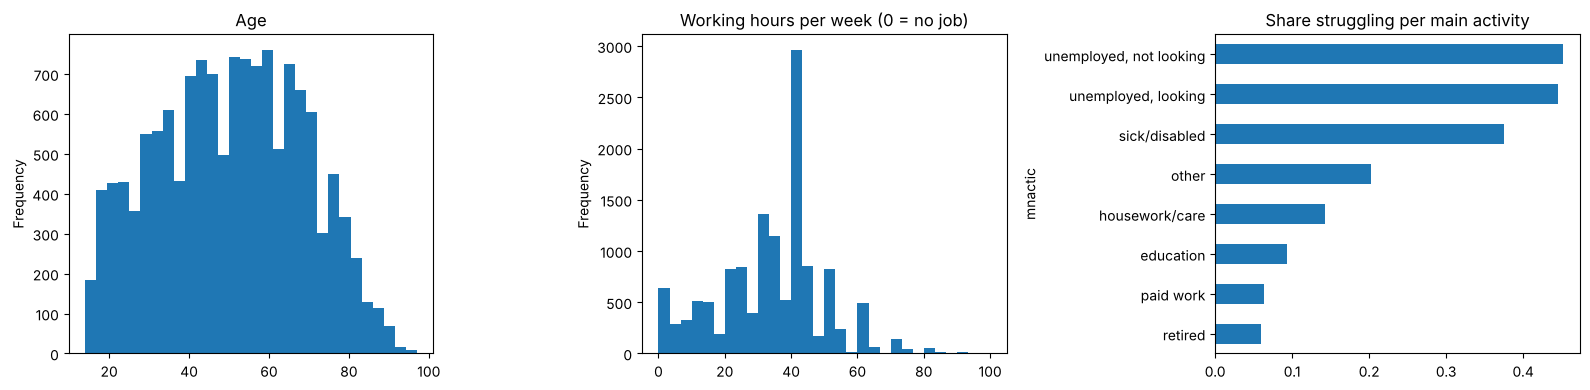

In [10]:
import matplotlib.pyplot as plt

activity = {1: "paid work", 2: "education", 3: "unemployed, looking", 4: "unemployed, not looking",
            5: "sick/disabled", 6: "retired", 8: "housework/care", 9: "other"}

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["agea"].plot.hist(bins=30, ax=ax[0], title="Age")
df["wkhtot"].plot.hist(bins=30, ax=ax[1], title="Working hours per week (0 = no job)")
(df.groupby(df["mnactic"].map(activity))["struggling"].mean()
   .sort_values().plot.barh(ax=ax[2], title="Share struggling per main activity"))
plt.tight_layout()
plt.show()

- Ages run from 14 to 97 (2 respondents of 14 in round 7; the ESS samples people aged 15+, but the age is calculated at the interview).
- Most people report the hours of their (current or last) job; 40 hours is by far the most common answer. Only about 4% report 0 hours (code 666, no job).
- People who are unemployed or sick/disabled struggle far more often (about 4 in 10) than people in paid work or retired people (about 6 in 100). Main activity and source of income will therefore be strong inputs.

## Step 3: Split first
We set aside 20% of the data as a test set before any preprocessing or tuning. We use `stratify=y` so that train and test both have 10% struggling people, and `random_state=42` so the split is the same every run. The test set is used exactly once, at the very end.

In [11]:
from sklearn.model_selection import train_test_split

features = ["agea", "hhmmb", "domicil", "eisced",
            "hincsrca", "mnactic", "uemp3m", "wkhtot"]

X = df[features]
y = df["struggling"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(10992, 8) (2748, 8)
0.10243813682678311 0.10225618631732168


## Step 4: Preprocessing inside a Pipeline
All preprocessing happens inside a scikit-learn `Pipeline` / `ColumnTransformer`, so it is fitted on the training data only and nothing leaks from the test set.

- **Numeric columns** (`agea`, `hhmmb`, `wkhtot`): missing values are filled with the median, then scaled with `StandardScaler`. Scaling is needed for KNN and logistic regression: KNN measures distances between people, and without scaling a column with large numbers (like age, 15–90) would dominate columns with small numbers (like 1–2). Logistic regression also trains more reliably when all columns are on the same scale.
- **Categorical columns** (`domicil`, `eisced`, `hincsrca`, `mnactic`, `uemp3m`): missing values are filled with the most frequent answer, then one-hot encoded. These codes are categories, not amounts: "retired" (6) is not twice "unemployed" (3).

**Everything we dropped:** 150 rows with an unknown target; the 13 survey-administration columns; `hincfel` (leakage); `hinctnta` (income unknown to the municipality); `chldhm` (not asked in 2018–2023); `gndr` and `brncntr` as inputs (kept for the fairness check).

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Real numbers
num_cols = ["agea", "hhmmb", "wkhtot"]
# Kinds of things (like shirt numbers)
cat_cols = ["domicil", "eisced", "hincsrca", "mnactic", "uemp3m"]

num_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # piece 1: fill gaps with the median
    ("scale", StandardScaler()),                    # piece 2: same scale for every column
])

cat_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # piece 1: fill gaps with the most common answer
    ("onehot", OneHotEncoder(handle_unknown="ignore")),   # piece 3: yes/no columns
])

preprocess = ColumnTransformer([
    ("num", num_steps, num_cols),
    ("cat", cat_steps, cat_cols),
])

## Step 5: Baseline
A `DummyClassifier` that always predicts the most common class ("not struggling"). We evaluate it with 5-fold stratified cross-validation on the training set, using F2. These same folds (`cv`) and this same metric (`f2`) are used for all models.

Result: F2 = 0.00 in every fold. The baseline never predicts "struggling", so it finds nobody (recall 0), even though its accuracy would be about 90%. This shows why accuracy is misleading here. Every model must beat F2 = 0.00.

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Our main metric: F2
f2 = make_scorer(fbeta_score, beta=2, zero_division=0)

# The same 5 folds for every model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent")),
])

scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring=f2)
print(scores)
print("F2 mean:", scores.mean(), "spread:", scores.std())

[0. 0. 0. 0. 0.]
F2 mean: 0.0 spread: 0.0


**Second baseline: a simple rule without machine learning.** Send a letter if the person's main income is a benefit (unemployment benefit or other social benefits), or if the person is unemployed or sick/disabled. A caseworker could apply this rule by hand. If our models cannot beat it, the municipality should just use the rule. The rule learns nothing, so we only score it on the validation part of the same 5 folds.

In [14]:
def simple_rule(X):
    # 1 = send a letter: main income is a benefit (5, 6), or main activity is unemployed or sick (3, 4, 5)
    return (X["hincsrca"].isin([5, 6]) | X["mnactic"].isin([3, 4, 5])).astype(int)

rule_scores = []
for train_idx, val_idx in cv.split(X_train, y_train):
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    rule_scores.append(fbeta_score(y_val, simple_rule(X_val), beta=2))
rule_scores = np.array(rule_scores)

print(rule_scores.round(3))
print("F2 mean:", rule_scores.mean().round(3), "spread:", rule_scores.std().round(3))

[0.452 0.428 0.44  0.464 0.426]
F2 mean: 0.442 spread: 0.014


The simple rule already reaches F2 ≈ 0.44, much better than the dummy. **This rule is the real bar to beat.**

## Step 6: Tune with cross-validation
All three models are tuned on the training set only, with the same 5 folds (`cv`), the same metric (F2) and the same threshold (10%), using `GridSearchCV`.

Best k: {'estimator__model__n_neighbors': 301} F2: 0.492


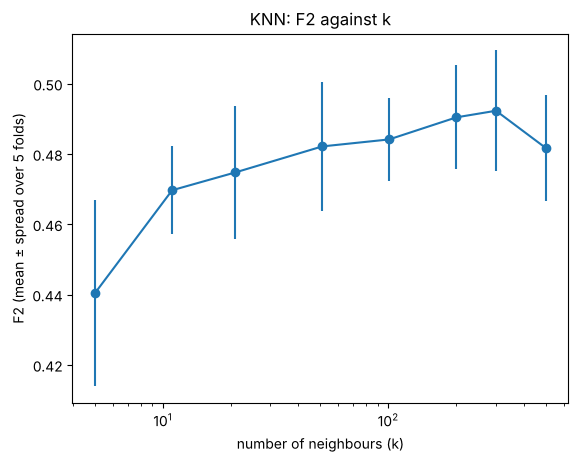

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import FixedThresholdClassifier
import matplotlib.pyplot as plt

# Same threshold for all models: "yes" if the chance is above average (10%)
THRESHOLD = 0.10

knn = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", KNeighborsClassifier()),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

knn_grid = GridSearchCV(
    knn,
    {"estimator__model__n_neighbors": [5, 11, 21, 51, 101, 201, 301, 501]},
    cv=cv, scoring=f2,
)
knn_grid.fit(X_train, y_train)

knn_results = pd.DataFrame(knn_grid.cv_results_)
print("Best k:", knn_grid.best_params_, "F2:", round(knn_grid.best_score_, 3))

# Plot: score against k
plt.errorbar(knn_results["param_estimator__model__n_neighbors"],
             knn_results["mean_test_score"],
             yerr=knn_results["std_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("number of neighbours (k)")
plt.ylabel("F2 (mean ± spread over 5 folds)")
plt.title("KNN: F2 against k")
plt.show()

**KNN:** best k = 301 (CV F2 ≈ 0.49). With few neighbours the score is low and unstable; it rises up to k = 301 and drops again at 501. From k ≈ 50 onward the error bars overlap, so the differences there are small. We use a fixed threshold of 10% for all models ("yes" if the predicted chance is above the average share of 10%), because with the default 50% almost nobody is predicted as struggling.

In [16]:
from sklearn.linear_model import LogisticRegression

logreg = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=1000)),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

logreg_grid = GridSearchCV(
    logreg,
    {"estimator__model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring=f2,
)
logreg_grid.fit(X_train, y_train)

logreg_results = pd.DataFrame(logreg_grid.cv_results_)
print("Best C:", logreg_grid.best_params_, "F2:", round(logreg_grid.best_score_, 3))
logreg_results[["param_estimator__model__C", "mean_test_score", "std_test_score"]]

Best C: {'estimator__model__C': 10} F2: 0.51


,param_estimator__model__C,mean_test_score,std_test_score
0,0.001,0.464435,0.018788
1,0.010,0.493269,0.015528
2,0.100,0.505060,0.012985
3,1.000,0.507988,0.013442
4,10.000,0.510136,0.013352
5,100.000,0.509394,0.012195


**Logistic regression:** best C = 10 (CV F2 ≈ 0.51). From C = 0.1 upward the scores are almost equal (0.505–0.510), and the differences are much smaller than the spread over the folds (±0.013). Only a very small C (0.001), which forces the model to be very simple, scores clearly lower.

**Check: is 10% a good threshold?** We fixed the threshold at 10% (the average share of struggling people) before comparing the models. Here we check that choice for logistic regression, on the training set only and with the same 5 folds: `cross_val_predict` gives every training person a predicted chance from the fold in which they were *not* used for training. Then we try a few thresholds. The test set stays untouched.

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

# The logistic regression pipeline with the best C, without the threshold
proba = cross_val_predict(logreg_grid.best_estimator_.estimator, X_train, y_train,
                          cv=cv, method="predict_proba")[:, 1]

rows = []
for t in [0.05, 0.08, 0.10, 0.15, 0.25]:
    pred = (proba >= t).astype(int)
    rows.append({"threshold": t,
                 "F2": fbeta_score(y_train, pred, beta=2),
                 "recall": recall_score(y_train, pred),
                 "precision": precision_score(y_train, pred),
                 "share getting a letter": pred.mean()})
pd.DataFrame(rows).round(3)

,threshold,F2,recall,precision,share getting a letter
0,0.05,0.463,0.877,0.160,0.560
1,0.08,0.499,0.727,0.221,0.337
2,0.10,0.510,0.667,0.263,0.260
3,0.15,0.487,0.539,0.352,0.157
4,0.25,0.419,0.407,0.478,0.087


**10% is also the best threshold for logistic regression** (F2 0.510). A lower threshold (5% or 8%) finds more people, but sends a letter to a third or more of all residents; a higher one (15% or 25%) sends fewer letters but misses many more people. 10% is also easy to explain: *a letter for everyone with a higher chance than average.* We keep the same 10% for all models, so the comparison stays fair.

In [18]:
from sklearn.tree import DecisionTreeClassifier

tree = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

tree_grid = GridSearchCV(
    tree,
    {"estimator__model__max_depth": [2, 3, 4, 5, 6, 8, 10, None]},
    cv=cv, scoring=f2,
)
tree_grid.fit(X_train, y_train)

tree_results = pd.DataFrame(tree_grid.cv_results_)
print("Best:", tree_grid.best_params_, "F2:", round(tree_grid.best_score_, 3))
tree_results[["param_estimator__model__max_depth", "mean_test_score", "std_test_score"]]

Best: {'estimator__model__max_depth': 6} F2: 0.465


,param_estimator__model__max_depth,mean_test_score,std_test_score
0,2,0.404376,0.017327
1,3,0.451136,0.006780
2,4,0.447522,0.010200
3,5,0.457372,0.017630
4,6,0.465441,0.017293
5,8,0.427160,0.016451
6,10,0.389819,0.018585
7,None,0.292025,0.029639


**Decision tree:** best `max_depth` = 6 (CV F2 ≈ 0.47). A shallow tree (depth 2) is too simple and underfits. Without a depth limit (`None`) the score drops to 0.29: the tree memorises the training data and fails on new data (overfitting).

## Step 7: Evaluate once on the test set
Each tuned model is evaluated exactly once on the test set. We show the confusion matrices and put the train, cross-validation and test scores side by side.

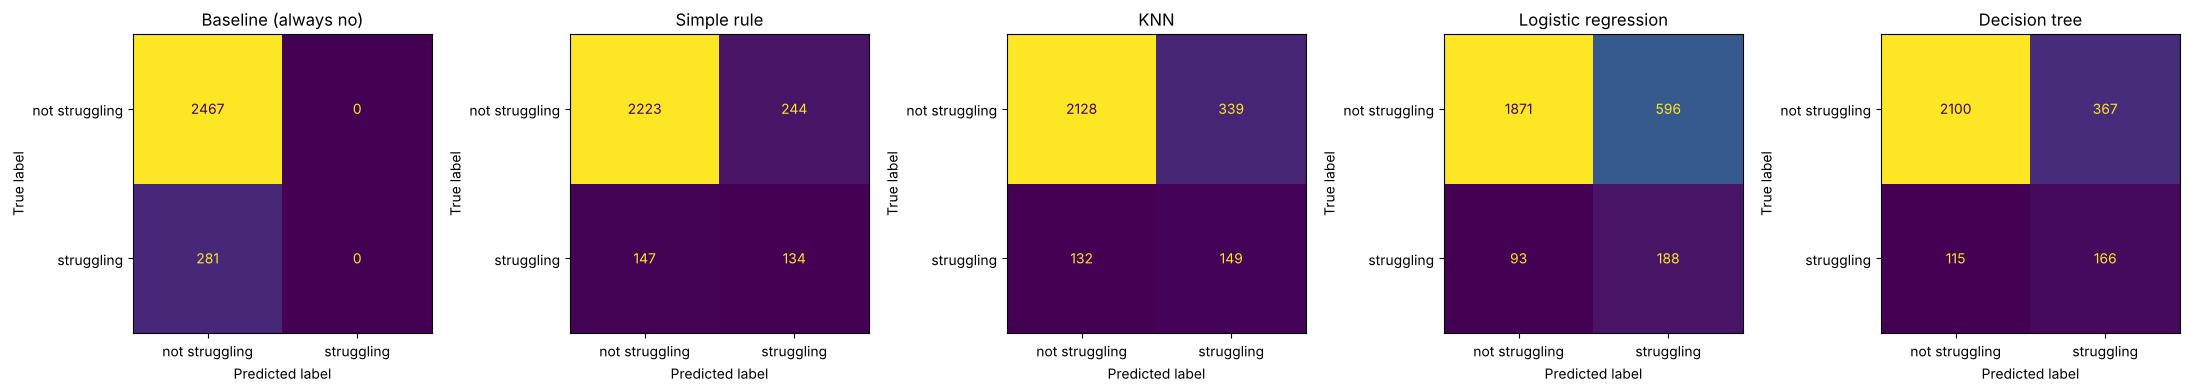

,model,best hyperparameter,train F2,CV F2 (mean ± spread),test F2,test precision,test recall,test F1,share getting a letter
0,Baseline (always no),–,0.000,0.000 ± 0.000,0.000,0.000,0.000,0.000,0.000
1,Simple rule,–,0.442,0.442 ± 0.014,0.446,0.354,0.477,0.407,0.138
2,KNN,n_neighbors = 301,0.502,0.492 ± 0.017,0.462,0.305,0.530,0.388,0.178
3,Logistic regression,C = 10,0.518,0.510 ± 0.013,0.493,0.240,0.669,0.353,0.285
4,Decision tree,max_depth = 6,0.514,0.465 ± 0.017,0.501,0.311,0.591,0.408,0.194


In [19]:
from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay

baseline.fit(X_train, y_train)

def cv_score(grid):
    i = grid.best_index_
    return f'{grid.cv_results_["mean_test_score"][i]:.3f} ± {grid.cv_results_["std_test_score"][i]:.3f}'

def best_params(grid):
    return ", ".join(f'{name.split("__")[-1]} = {value}' for name, value in grid.best_params_.items())

# Per candidate: best hyperparameter, CV score, predictions on train and on test
candidates = {
    "Baseline (always no)": ("–", f"{scores.mean():.3f} ± {scores.std():.3f}",
                             baseline.predict(X_train), baseline.predict(X_test)),
    "Simple rule": ("–", f"{rule_scores.mean():.3f} ± {rule_scores.std():.3f}",
                    simple_rule(X_train), simple_rule(X_test)),
}
for name, grid in [("KNN", knn_grid), ("Logistic regression", logreg_grid), ("Decision tree", tree_grid)]:
    model = grid.best_estimator_
    candidates[name] = (best_params(grid), cv_score(grid), model.predict(X_train), model.predict(X_test))

rows = []
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (params, cv_text, pred_train, pred_test)) in zip(axes, candidates.items()):
    rows.append({
        "model": name,
        "best hyperparameter": params,
        "train F2": fbeta_score(y_train, pred_train, beta=2, zero_division=0),
        "CV F2 (mean ± spread)": cv_text,
        "test F2": fbeta_score(y_test, pred_test, beta=2, zero_division=0),
        "test precision": precision_score(y_test, pred_test, zero_division=0),
        "test recall": recall_score(y_test, pred_test),
        "test F1": fbeta_score(y_test, pred_test, beta=1, zero_division=0),
        "share getting a letter": pred_test.mean(),
    })
    ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=ax, colorbar=False,
                                            display_labels=["not struggling", "struggling"])
    ax.set_title(name)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(rows).round(3)
os.makedirs("results", exist_ok=True)
comparison.to_csv("results/comparison_table.csv", index=False)
comparison

**Comparison (test set, used once):**
- All three models clearly beat the dummy baseline (F2 0.00).
- Against the **simple rule** (test F2 0.45), KNN is only slightly better (0.46). Logistic regression (0.49) and the decision tree (0.50) are clearly better. Logistic regression finds 188 of the 281 struggling people (recall 0.67), the rule 134 (recall 0.48). The price is more letters (28% of residents instead of 14%) and a lower precision (0.24 instead of 0.35).
- **Train vs CV vs test:** for KNN (0.50 / 0.49 / 0.46) and logistic regression (0.52 / 0.51 / 0.49) the three scores are close, so they do not overfit. If anything, logistic regression underfits a little: our 8 questions simply do not explain more. The decision tree scores clearly higher on train (0.51) than in CV (0.47), a sign of some overfitting. Its test score (0.50) is higher than its CV score; with a spread of ±0.017 over the folds that is probably luck with this particular test set, not a better model.
- For KNN and logistic regression the test score is 0.02–0.03 below the CV mean. With only 281 struggling people in the test set this is normal variation. It is no sign of leakage: a leaky pipeline would give a suspiciously *high* test score.
- Precision 0.24 means that of every 4 letters, about 1 goes to someone who really struggles.

## Step 8: Look at the errors
We check the logistic regression model per group on the test set: sex and country of birth (not used as input, kept aside for this check) and main activity.

In [20]:
best = logreg_grid.best_estimator_

# The test rows, with all original columns (also gndr and brncntr)
test = df.loc[X_test.index].copy()
test["predicted"] = best.predict(X_test)

def group_report(col, labels):
    rows = []
    for code, label in labels.items():
        g = test[test[col] == code]
        rows.append({
            "group": label,
            "people": len(g),
            "struggling": g["struggling"].sum(),
            "share struggling": g["struggling"].mean(),
            "share getting a letter": g["predicted"].mean(),
            "recall": recall_score(g["struggling"], g["predicted"]),
            "precision": precision_score(g["struggling"], g["predicted"], zero_division=0),
        })
    return pd.DataFrame(rows).round(2)

display(group_report("gndr", {1: "men", 2: "women"}))
display(group_report("brncntr", {1: "born in NL", 2: "born outside NL"}))
display(group_report("mnactic", {1: "paid work", 3: "unemployed, looking",
                                 5: "sick/disabled", 6: "retired", 8: "housework"}))

,group,people,struggling,share struggling,share getting a letter,recall,precision
0,men,1292,107,0.08,0.24,0.64,0.22
1,women,1456,174,0.12,0.33,0.68,0.25


,group,people,struggling,share struggling,share getting a letter,recall,precision
0,born in NL,2489,215,0.09,0.27,0.64,0.20
1,born outside NL,259,66,0.25,0.43,0.77,0.46


,group,people,struggling,share struggling,share getting a letter,recall,precision
0,paid work,1485,102,0.07,0.17,0.46,0.19
1,"unemployed, looking",61,23,0.38,0.92,1.00,0.41
2,sick/disabled,136,51,0.38,0.93,0.98,0.39
3,retired,519,33,0.06,0.15,0.27,0.12
4,housework,291,41,0.14,0.51,0.78,0.22


**Findings (logistic regression, test set):**
- Men and women are treated about equally (recall 0.64 vs 0.68).
- People born outside NL get a letter more often (43% vs 27%), but they also struggle almost 3 times as often (25% vs 9%). The model even finds them better (recall 0.77 vs 0.64), so they are not flagged without reason. Country of birth is not an input, but it may partly hide in other columns; we test that below.
- Retired people who struggle are found worst (recall 0.27), followed by working people (0.46). The model mainly learns "unemployed or sick = struggling"; people with a job or pension who still struggle (e.g. because of rent or debts) are mostly missed. Their problems are not in the data.
- Some groups are small (e.g. only 33 struggling retired people in the test set), so these numbers are uncertain.

**Is country of birth still hiding in our input columns?** We removed `brncntr` as an input, but other columns (source of income, education, unemployment history) may still give it away. Test: how well can our 8 input columns predict "born outside NL"? We use the training data only. ROC-AUC 0.5 means no information, 1.0 means a perfect stand-in.

In [21]:
born_outside = (df.loc[X_train.index, "brncntr"] == 2).astype(int)

proxy = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000)),
])
auc = cross_val_score(proxy, X_train, born_outside, cv=cv, scoring="roc_auc")
print(f"ROC-AUC: {auc.mean():.3f} ± {auc.std():.3f}")

ROC-AUC: 0.679 ± 0.014


ROC-AUC ≈ 0.68: our input columns predict country of birth moderately well. Removing the column did **not** fully remove the information: source of income, education and unemployment history partly stand in for it. For a voluntary offer of help this is acceptable (it even helps to reach a group that struggles more often), but it is one more reason why this model must never be used for checks or sanctions.

**Does the model still work in recent years?** The municipality would use the model now, not in 2008. We therefore also check the test set per survey round (`essround`, which we kept aside in step 2).

In [22]:
display(group_report("essround", {4: "2008", 5: "2010", 6: "2012", 7: "2014",
                                  8: "2016", 9: "2018", 10: "2020", 11: "2023"}))

,group,people,struggling,share struggling,share getting a letter,recall,precision
0,2008,333,29,0.09,0.30,0.66,0.19
1,2010,345,43,0.12,0.32,0.74,0.29
2,2012,359,54,0.15,0.35,0.61,0.26
3,2014,388,59,0.15,0.32,0.66,0.31
4,2016,351,34,0.10,0.32,0.79,0.24
5,2018,323,29,0.09,0.26,0.79,0.28
6,2020,291,13,0.04,0.21,0.46,0.10
7,2023,358,20,0.06,0.20,0.45,0.12


**The model works worst in the most recent rounds.** In 2020 and 2023 fewer people struggle (4–6% instead of 9–15%), and the model finds only about 45% of them, against 61–79% in 2008–2018. Only about 1 in 9 letters would reach someone who really struggles. The groups are small (13 and 20 struggling people), so these numbers are uncertain, but the direction is a warning: the model learned mostly from years in which more people struggled, and the most recent rounds are the closest to the moment the municipality would use it. Before real use, the model must be tested on recent data from the municipality itself.

## Step 9: Recommendation
Before we choose a model, one more check on the decision in our pipeline we would defend hardest: leaving out income.

**What does leaving out income cost?** We do not use income (`hinctnta`), because the municipality does not know it. To make that choice concrete, we train the same logistic regression (same C, same threshold, same folds) with income added. Training set only; the test set stays untouched. Codes 77/88/99 in income mean refusal or "don't know".

In [23]:
X_train_inc = df.loc[X_train.index, features + ["hinctnta"]].copy()
X_train_inc["hinctnta"] = X_train_inc["hinctnta"].replace([77, 88, 99], np.nan)

preprocess_inc = ColumnTransformer([
    ("num", num_steps, num_cols),
    ("cat", cat_steps, cat_cols + ["hinctnta"]),
])
logreg_inc = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess_inc),
        ("model", LogisticRegression(max_iter=1000, C=logreg_grid.best_params_["estimator__model__C"])),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)
inc_scores = cross_val_score(logreg_inc, X_train_inc, y_train, cv=cv, scoring=f2)
print(f"without income: CV F2 {cv_score(logreg_grid)}")
print(f"with income:    CV F2 {inc_scores.mean():.3f} ± {inc_scores.std():.3f}")

without income: CV F2 0.510 ± 0.013
with income:    CV F2 0.590 ± 0.023


Income would raise the CV F2 from 0.51 to 0.59, more than the difference between any of our models. We still leave it out: the municipality does not know the income of every resident, and collecting it only to rank residents goes further than acting on concrete payment-arrears signals. **We prefer a slightly weaker model that only uses information the user may realistically use.**

We recommend **logistic regression** to the municipality's debt-support team.
- It misses the fewest people who struggle (93 of 281 in the test set; recall 0.67). Missing someone is the worst mistake for our user.
- It clearly beats the simple rule (F2 0.49 vs 0.45; it finds 188 instead of 134 struggling people), so machine learning adds something over a rule a caseworker could apply by hand.
- It has the best and most stable cross-validation score (F2 0.51 ± 0.013), and train, CV and test scores are close, so it does not overfit.
- The decision tree has a slightly higher test F2 (0.50 vs 0.49), but the difference is smaller than the spread over the folds, its CV score is lower (0.47), and it misses 22 more people.
- Logistic regression is explainable: each answer has one weight, so the municipality can tell a resident why they received a letter.

**But only as a voluntary offer of help**, next to existing signals such as payment arrears. About 3 in 4 letters go to people who manage fine (precision 0.24), the model sends a letter to about 28% of residents, and retired and working people who struggle are often missed. In the most recent rounds (2020 and 2023) it found only about 45% of the struggling people, so it must first be tested on recent, local data. If the team cannot handle that many letters, it can raise the threshold: fewer letters, but more people missed. The model must never be used to cut benefits or to check people.

## Step 10: Use it
A new, made-up resident: 45 years old, household of 3, lives in a big city, lower secondary education, main income from social benefits, unemployed and looking for work, has been unemployed for more than 3 months before, works 0 hours.

In [24]:
new_person = pd.DataFrame([{
    "agea": 45,       # age
    "hhmmb": 3,       # people in household
    "domicil": 1,     # big city
    "eisced": 2,      # lower secondary education
    "hincsrca": 6,    # main income: social benefits
    "mnactic": 3,     # unemployed, looking for a job
    "uemp3m": 1,      # ever unemployed > 3 months: yes
    "wkhtot": 0,      # working hours per week
}])

prediction = best.predict(new_person)[0]
probability = best.predict_proba(new_person)[0, 1]

print("Prediction:", "struggling → send a letter" if prediction == 1 else "not struggling → no letter")
print(f"Chance of struggling: {probability:.0%} (threshold {THRESHOLD:.0%})")

Prediction: struggling → send a letter
Chance of struggling: 83% (threshold 10%)


## Ethical reflection

**Who is in the data, and who is missing.** Dutch residents aged 15+ living in private households, interviewed between 2008 and 2023; about 9% were born outside the Netherlands. Missing are people in care homes and other institutions, homeless people, asylum seekers, people who could not do the interview in Dutch and people who refused to take part. These are probably among the people who struggle most. The data ends before the full effect of the 2022–2023 price rises, and we did not use the survey weights.

**Does the model make the same mistakes for every group?** For men and women, yes (recall 0.64 vs 0.68). People born outside NL get a letter more often (43% vs 27%), but they also struggle about 3 times as often and the model finds them better (recall 0.77 vs 0.64). The clearest gaps are by main activity and by year: the model finds only 27% of struggling retired people and 46% of struggling working people, and in the most recent rounds (2020 and 2023) only about 45% of all struggling people, against 61–79% before. The model knows the past better than the present.

**Is a removed column still hiding in another one?** Yes, partly. We did not give sex, country of birth or income to the model, but our input columns still predict "born outside NL" with ROC-AUC 0.68 (0.5 = no information).

**What a mistake costs the person.** A false negative means a struggling household gets no early help, and debts can grow until a landlord or energy company reports arrears. A false positive means an unnecessary letter, which can feel intrusive or stigmatising, especially for people born outside NL, who get letters more often and may feel singled out after the childcare-benefits scandal.

**Consent and licence.** The respondents agreed to take part in a scientific survey, not to being scored by a municipality. The CC BY-NC-SA 4.0 licence allows our non-commercial, educational use with attribution; it would not allow commercial use. Real use would need the municipality's own data and a privacy impact assessment (DPIA).

**What we did about these risks:**
1. We chose F2 and a low threshold (10%), so that fewer struggling people are missed.
2. We left sex, country of birth and income out of the model.
3. We checked the errors per sex, country of birth, main activity and survey year, and tested whether country of birth hides in the other columns.
4. We wrote a warning in the README: **do not use this model** for any decision with negative consequences for a resident (cutting benefits, fraud checks, sanctions, credit), as the only way to find people, or for retired people without extra attention, or in real use before it has been tested on recent data from the municipality itself.

In [25]:
# Versions used for the saved outputs above
import sys, sklearn, matplotlib
print("Python", sys.version.split()[0])
for lib in [np, pd, sklearn, matplotlib]:
    print(lib.__name__, lib.__version__)

Python 3.13.16
numpy 2.5.3
pandas 3.0.5
sklearn 1.9.1
matplotlib 3.11.2
